In [206]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings
import ast

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

# 통계검정
from scipy.stats import chi2_contingency

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)
""
print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [207]:
df = pd.read_csv('../Myun_EDA/preprocessed_final.csv')
sorted_df = df.sort_values(by=['customer_id','time'])

In [208]:
df['offer_id'].value_counts()

offer_id
fafdcd668e3743c1bb461111dcafc2a4    20241
2298d6c36e964ae4a3e7e9706d1fb8c2    20139
f19421c1d4aa40978ebb69ca19b0e20d    19131
4d5c57ea9a6940dd891ad53e9dbe8da0    18222
ae264e3637204a6fb9bb56bc8210ddfd    18062
9b98b8c7a33c4b65b9aebfe6a799e6d9    16202
2906b810c7d4411798c6938adc9daaa5    15767
5a8bc65990b245e5a138643cd4eb9837    14305
0b1e1539f2cc45b7b9fa7c272da2e1d7    13751
3f207df678b143eea3cee63160fa8bed    11761
Name: count, dtype: int64

In [209]:
df[df['event']=='offer completed']['offer_id'].value_counts() # offer completed 인 offer는 8개 (10개 중)

offer_id
fafdcd668e3743c1bb461111dcafc2a4    5317
2298d6c36e964ae4a3e7e9706d1fb8c2    5156
9b98b8c7a33c4b65b9aebfe6a799e6d9    4354
f19421c1d4aa40978ebb69ca19b0e20d    4296
2906b810c7d4411798c6938adc9daaa5    4017
ae264e3637204a6fb9bb56bc8210ddfd    3688
0b1e1539f2cc45b7b9fa7c272da2e1d7    3420
4d5c57ea9a6940dd891ad53e9dbe8da0    3331
Name: count, dtype: int64

In [210]:
df

,customer_id,event,time,amount,offer_id,day,reward,difficulty,duration,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,gender,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.00,0.0,F,75.0,2017-05-09,100000.0,0,60대 이상,60+ 여성,10만 이상
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0,2.0,0.25,-15.0,Unknown,NaN,2017-08-04,0.0,1,누락,미기입,누락
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0,3.0,0.20,-8.0,M,68.0,2018-04-26,70000.0,0,60대 이상,60대 남성,5-7.5만
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0,4.0,0.20,-8.0,Unknown,NaN,2017-09-25,0.0,1,누락,미기입,누락
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.00,0.0,Unknown,NaN,2017-10-02,0.0,1,누락,미기입,누락
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,66.0,2018-01-01,47000.0,0,60대 이상,60대 남성,5만 미만
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,52.0,2018-04-08,62000.0,0,50대,50대 남성,5-7.5만
306531,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,63.0,2013-09-22,52000.0,0,60대 이상,60대 여성,5-7.5만
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,57.0,2016-07-09,40000.0,0,50대,50대 남성,5만 미만


In [211]:
# ==========================
# viewed 이후 completed 이벤트 플래그
# 이벤트를 인지하고 결제가 이루어졌는지를 확인하는 용도
# is_aware == True : offer가 구매에 영향을 주었을 가능성 높음 (마케팅 효과 있음)
# is_aware == False : 오퍼를 보기 전에 이미 구매했거나 오퍼 존재 자체를 모른체 구매 (마케팅 효과 없음)
# ==========================

# 1. 필수 전제조건: asof를 쓰려면 반드시 기준이 되는 컬럼(여기선 'time')이 오름차순 정렬되어 있어야 함
df_view = df[df['event'] == 'offer viewed'][['customer_id', 'offer_id', 'time']] # view 이벤트 테이블
df_complete = df[df['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']] # complete 이벤트 테이블
df_receive = df[df['event'] == 'offer received'][['customer_id', 'offer_id', 'time']] # receive 이벤트 테이블

df_view = df_view.sort_values('time')
df_view['time_view'] = df_view['time']
df_complete = df_complete.sort_values('time')
df_complete['time_comp'] = df_complete['time']
df_receive = df_receive.sort_values('time')
df_receive['time_rece'] = df_receive['time']

# 2. merge_asof 적용
# df_view를 기준으로, '이전(backward)'에 발생한 가장 가까운 df_complete의 시간을 붙여줌
merged_df_comp = pd.merge_asof(
    df_complete,                  # 왼쪽 기준 테이블 (완료)
    df_view,              # 오른쪽 갖다 붙일 테이블 (조회)
    on='time',                # 시간 축 (반드시 정렬되어 있어야 함)
    by=['customer_id', 'offer_id'], # 그룹화할 키 (이 안에서만 시간을 비교)
    direction='backward',      # '완료' 이전의 '조회'를 찾아야 하므로 backward! 
    allow_exact_matches=False # <--- [핵심] 무조건 조회 시간이 완료 시간보다 '작을' 때만 매칭!
)
merged_df_comp['is_aware'] = merged_df_comp['time_view'].notna() # 결측치가 아니면 True 반환

# 병합 전과 후의 행 수 확인
print(f"병합 전 : {len(df_complete)}, 병합 후 : {len(merged_df_comp)}")
display(merged_df_comp)

병합 전 : 33579, 병합 후 : 33579


,customer_id,offer_id,time,time_comp,time_view,is_aware
0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,2906b810c7d4411798c6938adc9daaa5,0,0,NaN,False
1,a8fcc392843343428db13c0814f7d5b3,ae264e3637204a6fb9bb56bc8210ddfd,0,0,NaN,False
2,11edb6a7da284f19a8a1da5e7c0c9652,4d5c57ea9a6940dd891ad53e9dbe8da0,0,0,NaN,False
3,b34eb5a525e5497897275dcd8b5e7ff2,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,0,NaN,False
4,ed84d24d38fd43feab88ed5c6a489124,4d5c57ea9a6940dd891ad53e9dbe8da0,0,0,NaN,False
...,...,...,...,...,...,...
33574,25417089cb08467a94811abf01e1796f,fafdcd668e3743c1bb461111dcafc2a4,714,714,588.0,True
33575,004b041fbfe44859945daa2c7f79ee64,fafdcd668e3743c1bb461111dcafc2a4,714,714,576.0,True
33576,0222d267445f4f078bc325224e471766,2906b810c7d4411798c6938adc9daaa5,714,714,NaN,False
33577,6d9ee24c5889452e800b7d700f29b01e,ae264e3637204a6fb9bb56bc8210ddfd,714,714,606.0,True


merged_df는 customer_id당 같은 offer_id별로 event=='offer complete'인 한 건만 포함

In [212]:
merged_df_comp['offer_id'].value_counts()

offer_id
fafdcd668e3743c1bb461111dcafc2a4    5317
2298d6c36e964ae4a3e7e9706d1fb8c2    5156
9b98b8c7a33c4b65b9aebfe6a799e6d9    4354
f19421c1d4aa40978ebb69ca19b0e20d    4296
2906b810c7d4411798c6938adc9daaa5    4017
ae264e3637204a6fb9bb56bc8210ddfd    3688
0b1e1539f2cc45b7b9fa7c272da2e1d7    3420
4d5c57ea9a6940dd891ad53e9dbe8da0    3331
Name: count, dtype: int64

In [213]:
# ==========================
# viewed 이후 completed 이벤트 플래그
# 이벤트를 인지하고 결제가 이루어졌는지를 확인하는 용도
# is_converted == True : offer가 구매에 영향을 주었을 가능성 높음 (마케팅 효과 있음)
# is_converted == False : 오퍼를 봤으나 구매로 이어지지 않은 경우
# ==========================

# 2. merge_asof 적용
# df_view를 기준으로, '이후(forward)'에 발생한 가장 가까운 df_complete의 시간을 붙여줌
merged_df_view = pd.merge_asof(
    df_view,                  # 왼쪽 기준 테이블 (조회)
    df_complete,              # 오른쪽 갖다 붙일 테이블 (완료)
    on='time',                # 시간 축 (반드시 정렬되어 있어야 함)
    by=['customer_id', 'offer_id'], # 그룹화할 키 (이 안에서만 시간을 비교)
    direction='forward',      # '조회' 이후의 '완료'를 찾아야 하므로 forward! (과거를 찾을 땐 backward)
    suffixes=('_view', '_comp')
)
merged_df_view['is_converted'] = merged_df_view['time_comp'].notna() # 결측치가 아니면 True 반환
merged_df_view['view_to_comp'] = merged_df_view['time_comp'] - merged_df_view['time_view']

# 병합 전과 후의 행 수 확인
print(f"병합 전 : {len(df_view)}, 병합 후 : {len(merged_df_view)}")
display(merged_df_view)

병합 전 : 57725, 병합 후 : 57725


,customer_id,offer_id,time,time_view,time_comp,is_converted,view_to_comp
0,389bc3fa690240e798340f5a15918d5c,f19421c1d4aa40978ebb69ca19b0e20d,0,0,60.0,True,60.0
1,bf5783772fee4f2ab126f07bf3be80f1,4d5c57ea9a6940dd891ad53e9dbe8da0,0,0,0.0,True,0.0
2,14cbeafc2297453e9bf4924c2eabe35e,fafdcd668e3743c1bb461111dcafc2a4,0,0,12.0,True,12.0
3,324cde983eef4759ace1e2e30816b751,2298d6c36e964ae4a3e7e9706d1fb8c2,0,0,NaN,False,NaN
4,79e3b16de4964b6c82e45e0014a42502,5a8bc65990b245e5a138643cd4eb9837,0,0,NaN,False,NaN
...,...,...,...,...,...,...,...
57720,4d3857fcab6344aca68ebe2eaffa32c0,5a8bc65990b245e5a138643cd4eb9837,714,714,NaN,False,NaN
57721,c830751fd5de4453a105b0bd54aa070f,3f207df678b143eea3cee63160fa8bed,714,714,NaN,False,NaN
57722,e211ccfbd319454490cbfbeeb6f3da5e,ae264e3637204a6fb9bb56bc8210ddfd,714,714,NaN,False,NaN
57723,df1e6d50effb4af28aff99f69fd3f394,5a8bc65990b245e5a138643cd4eb9837,714,714,NaN,False,NaN


In [214]:
# ==========================
# received 이후 view가 일어날때까지 걸린 시간 확인
# ==========================

# 2. merge_asof 적용
# df_view를 기준으로, '이후(forward)'에 발생한 가장 가까운 df_view의 시간을 붙여줌
merged_df_rece = pd.merge_asof(
    df_receive,                  # 왼쪽 기준 테이블 (받음)
    df_view,              # 오른쪽 갖다 붙일 테이블 (조회)
    on='time',                # 시간 축 (반드시 정렬되어 있어야 함)
    by=['customer_id', 'offer_id'], # 그룹화할 키 (이 안에서만 시간을 비교)
    direction='forward'      # '받음' 이후의 '조회'를 찾아야 하므로 forward! (과거를 찾을 땐 backward)
)
merged_df_rece['rece_to_view'] = merged_df_rece['time_view'] - merged_df_rece['time_rece']

# 병합 전과 후의 행 수 확인
print(f"병합 전 : {len(df_receive)}, 병합 후 : {len(merged_df_rece)}")
display(merged_df_rece)

병합 전 : 76277, 병합 후 : 76277


,customer_id,offer_id,time,time_rece,time_view,rece_to_view
0,78afa995795e4d85b5d9ceeca43f5fef,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,0,6.0,6.0
1,05c001b0be8a436dba8f7fdb7ac9273b,5a8bc65990b245e5a138643cd4eb9837,0,0,90.0,90.0
2,64257c0ea273425d8821644f040b79d9,fafdcd668e3743c1bb461111dcafc2a4,0,0,0.0,0.0
3,353697e3573c49cebed67da5d6fb49f9,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,0,84.0,84.0
4,aff95fbae22348daa57ca6ef60a85f8c,2298d6c36e964ae4a3e7e9706d1fb8c2,0,0,6.0,6.0
...,...,...,...,...,...,...
76272,284650de773c461da7dd5c547e5ac590,f19421c1d4aa40978ebb69ca19b0e20d,576,576,594.0,18.0
76273,b9856bf1ebd14d05a9a34df2e1d5008d,2906b810c7d4411798c6938adc9daaa5,576,576,NaN,NaN
76274,b69d33d582fa4ffbbe9f1fd022f24463,5a8bc65990b245e5a138643cd4eb9837,576,576,606.0,30.0
76275,97c0d21869cf456089910a992fe39e77,5a8bc65990b245e5a138643cd4eb9837,576,576,588.0,12.0


In [215]:
# 이 time은 원래 해당 이벤트가 발생했던 정확한 시점
merged_df_comp = merged_df_comp[['customer_id', 'offer_id', 'time', 'is_aware']].copy()
merged_df_view = merged_df_view[['customer_id', 'offer_id', 'time', 'view_to_comp', 'is_converted']].copy()
merged_df_rece = merged_df_rece[['customer_id', 'offer_id', 'time', 'rece_to_view']].copy()

merged_df_comp['event'] = 'offer completed'
merged_df_view['event'] = 'offer viewed'
merged_df_rece['event'] = 'offer received'

In [216]:
# 전체 데이터프레임과 rece_to_view, is_aware, is_converted 포함한 데이터프레임 병합
full_df = pd.merge(df, merged_df_rece, on=['customer_id', 'offer_id', 'time', 'event'], how='left')
full_df = pd.merge(full_df, merged_df_comp, on=['customer_id', 'offer_id', 'time', 'event'], how='left')
full_df = pd.merge(full_df, merged_df_view, on=['customer_id', 'offer_id', 'time', 'event'], how='left')
full_df

,customer_id,event,time,amount,offer_id,day,reward,difficulty,duration,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,gender,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group,rece_to_view,is_aware,view_to_comp,is_converted
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.00,0.0,F,75.0,2017-05-09,100000.0,0,60대 이상,60+ 여성,10만 이상,6.0,NaN,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,0,5.0,20.0,10.0,discount,1.0,1.0,0.0,0.0,2.0,0.25,-15.0,Unknown,NaN,2017-08-04,0.0,1,누락,미기입,누락,6.0,NaN,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,NaN,2906b810c7d4411798c6938adc9daaa5,0,2.0,10.0,7.0,discount,1.0,1.0,1.0,0.0,3.0,0.20,-8.0,M,68.0,2018-04-26,70000.0,0,60대 이상,60대 남성,5-7.5만,18.0,NaN,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,0,2.0,10.0,10.0,discount,1.0,1.0,1.0,1.0,4.0,0.20,-8.0,Unknown,NaN,2017-09-25,0.0,1,누락,미기입,누락,12.0,NaN,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.00,0.0,Unknown,NaN,2017-10-02,0.0,1,누락,미기입,누락,84.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307325,b3a1272bc9904337b331bf348c3e8c17,transaction,714,1.59,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,66.0,2018-01-01,47000.0,0,60대 이상,60대 남성,5만 미만,NaN,NaN,NaN,NaN
307326,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,9.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,52.0,2018-04-08,62000.0,0,50대,50대 남성,5-7.5만,NaN,NaN,NaN,NaN
307327,a00058cf10334a308c68e7631c529907,transaction,714,3.61,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,F,63.0,2013-09-22,52000.0,0,60대 이상,60대 여성,5-7.5만,NaN,NaN,NaN,NaN
307328,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,3.53,NaN,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,M,57.0,2016-07-09,40000.0,0,50대,50대 남성,5만 미만,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================
# 오퍼별 성과 분석
# ==========================================

# 1. 오퍼 마스터 테이블
offer_info = df.dropna(subset=['offer_id'])[['offer_id', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 
                 'offer_type', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength']].drop_duplicates().set_index('offer_id')

# 2. Boolean 컬럼의 평균(mean)을 활용한 초간단 비율 계산!
# 발송 수 (size = 행 개수)
received_count = full_df[full_df['event'] == 'offer received'].groupby('offer_id').size().rename('received_count')

# 평균 인지 소요 시간 계산
# 'offer received' 이벤트 행에 있는 rece_to_view 값들의 평균 (NaN은 자동 제외됨)
avg_rece_to_view = full_df[full_df['event'] == 'offer received'].groupby('offer_id')['rece_to_view'].mean().rename('avg_rece_to_view')

# 인지율: '완료(completed)' 이벤트 중 is_aware 가 True인 비율
aware_rate = full_df[full_df['event'] == 'offer completed'].groupby('offer_id')['is_aware'].mean().rename('aware_rate')

# 전환율: '조회(viewed)' 이벤트 중 is_converted 가 True인 비율
conversion_rate = full_df[full_df['event'] == 'offer viewed'].groupby('offer_id')['is_converted'].mean().rename('conversion_rate')

# 3. 데이터 한 번에 합치기 (join 활용)
analysis_df = offer_info.join([received_count, avg_rece_to_view, aware_rate, conversion_rate]).reset_index()

# 4. 보기 좋게 퍼센트로 변환 및 정렬
analysis_df['aware_rate'] = analysis_df['aware_rate'] * 100
analysis_df['conversion_rate'] = analysis_df['conversion_rate'] * 100

display(analysis_df.sort_values('conversion_rate', ascending=False))

,offer_id,ch_web,ch_email,ch_mobile,ch_social,channel_count,offer_type,duration,reward,difficulty,reward_ratio,offer_strength,received_count,avg_rece_to_view,aware_rate,conversion_rate
3,fafdcd668e3743c1bb461111dcafc2a4,1.0,1.0,1.0,1.0,4.0,discount,10.0,2.0,10.0,0.200000,-8.0,7597,21.639745,84.283343,66.12529
6,2298d6c36e964ae4a3e7e9706d1fb8c2,1.0,1.0,1.0,1.0,4.0,discount,7.0,3.0,7.0,0.428571,-4.0,7646,21.732431,80.911518,63.1457
2,2906b810c7d4411798c6938adc9daaa5,1.0,1.0,1.0,0.0,3.0,discount,7.0,2.0,10.0,0.200000,-8.0,7632,47.762939,54.111084,55.439534
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,1.0,1.0,1.0,0.0,3.0,bogo,7.0,5.0,5.0,1.000000,0.0,7677,48.329685,48.608618,54.902901
5,f19421c1d4aa40978ebb69ca19b0e20d,1.0,1.0,1.0,1.0,4.0,bogo,5.0,5.0,5.0,1.000000,0.0,7571,21.488258,75.985335,52.546806
1,0b1e1539f2cc45b7b9fa7c272da2e1d7,1.0,1.0,0.0,0.0,2.0,discount,10.0,5.0,20.0,0.250000,-15.0,7668,59.504587,41.429369,52.234322
8,ae264e3637204a6fb9bb56bc8210ddfd,0.0,1.0,1.0,1.0,3.0,bogo,7.0,10.0,10.0,1.000000,0.0,7658,31.759742,68.766473,41.751042
4,4d5c57ea9a6940dd891ad53e9dbe8da0,1.0,1.0,1.0,1.0,4.0,bogo,5.0,10.0,10.0,1.000000,0.0,7593,21.648903,77.499263,40.600164
7,3f207df678b143eea3cee63160fa8bed,1.0,1.0,1.0,0.0,3.0,informational,4.0,0.0,0.0,0.000000,0.0,7617,46.941339,NaN,0.0
9,5a8bc65990b245e5a138643cd4eb9837,0.0,1.0,1.0,1.0,3.0,informational,3.0,0.0,0.0,0.000000,0.0,7618,31.278978,NaN,0.0


### 1. 마케팅 효과 별로였던(인지율이 낮았던) 세 오퍼 확인
#### 다른 오퍼들과 비교해봤을 때 conversion_rate에 비해 aware_rate이 상대적으로 낮은 오퍼는 소셜 채널을 이용하지 않았다는 특징이 있었다

### 2. 소셜 채널을 이용하지 않은 네 오퍼들은 모두 평균 receive to view에 걸린 시간이 길었다

### 3. 전환율 측면에서는 discount type 보다 bogo 오퍼가 전환율이 낮은 경향이 있었다
#### bogo 오퍼의 경우 이벤트를 인지했지만 완료 액션까지 이어진 비율이 더 낮았다

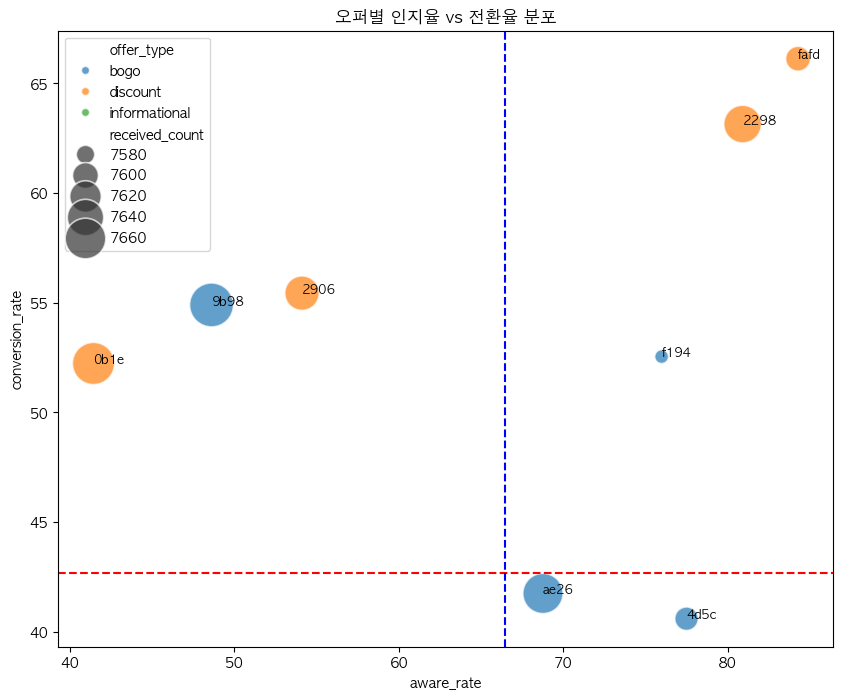

In [218]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=analysis_df, x='aware_rate', y='conversion_rate', 
                size='received_count', hue='offer_type', sizes=(100, 1000), alpha=0.7)

# 오퍼 id 점 옆에 표시
for i in range(analysis_df.shape[0]):
    plt.text(analysis_df.aware_rate[i], analysis_df.conversion_rate[i], 
             analysis_df.offer_id[i][:4], fontsize=9) # ID 앞 4자리만

plt.title('오퍼별 인지율 vs 전환율 분포')
plt.axhline(analysis_df['conversion_rate'].mean(), color='red', linestyle='--') # 평균선
plt.axvline(analysis_df['aware_rate'].mean(), color='blue', linestyle='--') # 평균선
plt.show()

### -> 우상단 : 효자상품 vs 좌상단 : 마케팅 전략을 더 잘 세워서 인지율을 높이도록!
#### 좌상단의 세 오퍼는 모두 ch_social==0인 오퍼!!

In [219]:
# '매력적인 오퍼'가 정말 '인지'와 '전환'도 잘 되고 있는지 상관관계 확인
correlation = analysis_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'avg_rece_to_view', 'aware_rate', 'conversion_rate']].corr()
display(correlation)

,channel_count,duration,reward,difficulty,reward_ratio,offer_strength,avg_rece_to_view,aware_rate,conversion_rate
channel_count,1.000000,-0.177287,0.110240,-0.313328,0.319470,0.424652,-0.909425,0.922045,0.291051
duration,-0.177287,1.000000,0.160262,0.808414,-0.012028,-0.791110,0.226213,-0.289430,0.767067
reward,0.110240,0.160262,1.000000,0.465686,0.844821,0.165871,-0.204906,0.059031,0.340848
difficulty,-0.313328,0.808414,0.465686,1.000000,0.125191,-0.795447,0.278927,-0.467402,0.620937
reward_ratio,0.319470,-0.012028,0.844821,0.125191,1.000000,0.439035,-0.310330,0.135473,0.396691
offer_strength,0.424652,-0.791110,0.165871,-0.795447,0.439035,1.000000,-0.451145,0.433684,-0.458528
avg_rece_to_view,-0.909425,0.226213,-0.204906,0.278927,-0.310330,-0.451145,1.000000,-0.984323,-0.156575
aware_rate,0.922045,-0.289430,0.059031,-0.467402,0.135473,0.433684,-0.984323,1.000000,0.165184
conversion_rate,0.291051,0.767067,0.340848,0.620937,0.396691,-0.458528,-0.156575,0.165184,1.000000


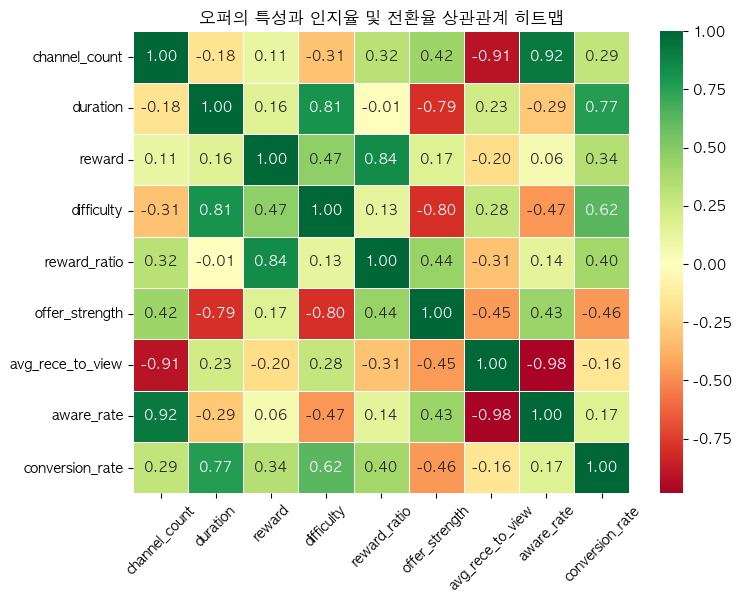

In [220]:
# 히트맵 (전체적인 상관관계 파악)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
plt.title('오퍼의 특성과 인지율 및 전환율 상관관계 히트맵')
plt.xticks(rotation=45)
plt.show()

In [221]:
discount_df = analysis_df[analysis_df['offer_type']=='discount']
bogo_df = analysis_df[analysis_df['offer_type']=='bogo']

discount_corr = discount_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'avg_rece_to_view', 'aware_rate', 'conversion_rate']].corr()
print("discount 오퍼의 특성과 인지율 및 전환율의 상관관계:\n", discount_corr)

bogo_corr = bogo_df[['channel_count', 'duration', 'reward', 'difficulty', 'reward_ratio', 'offer_strength', 'avg_rece_to_view', 'aware_rate', 'conversion_rate']].corr()
print("bogo 오퍼의 특성과 인지율 및 전환율의 상관관계:\n", bogo_corr)

discount 오퍼의 특성과 인지율 및 전환율의 상관관계:
                   channel_count  duration    reward  difficulty  reward_ratio  \
channel_count          1.000000 -0.301511 -0.738549   -0.904274      0.349394   
duration              -0.301511  1.000000  0.408248    0.660827     -0.474921   
reward                -0.738549  0.408248  1.000000    0.830097      0.217152   
difficulty            -0.904274  0.660827  0.830097    1.000000     -0.364056   
reward_ratio           0.349394 -0.474921  0.217152   -0.364056      1.000000   
offer_strength         0.894468 -0.694314 -0.721515   -0.985022      0.519198   
avg_rece_to_view      -0.982703  0.176452  0.613523    0.819970     -0.410643   
aware_rate             0.980134 -0.129153 -0.629052   -0.803146      0.355253   
conversion_rate        0.955568 -0.010043 -0.621327   -0.739852      0.257358   

                  offer_strength  avg_rece_to_view  aware_rate  \
channel_count           0.894468         -0.982703    0.980134   
duration              

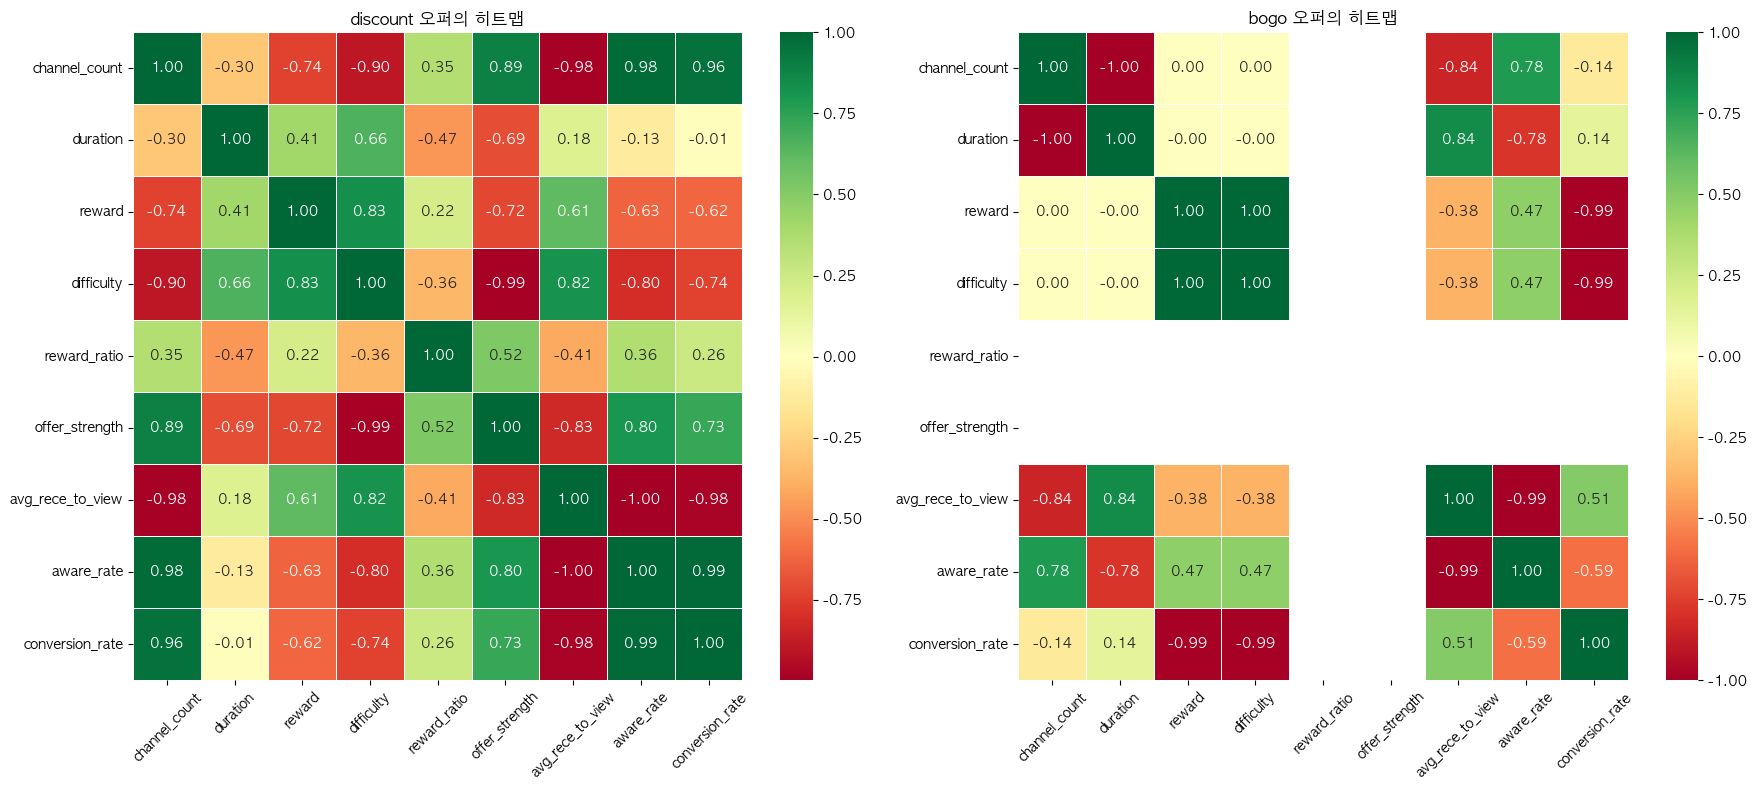

In [222]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

ax1 = axes[0]
ax2 = axes[1]
label = ['discount', 'bogo']

sns.heatmap(discount_corr, ax=ax1, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)
sns.heatmap(bogo_corr, ax=ax2, annot=True, cmap='RdYlGn', center=0, fmt='.2f', linewidths=0.5)

for ax in [ax1, ax2]:
    ax.tick_params(axis='x', rotation=45)

ax1.set_title(f"{label[0]} 오퍼의 히트맵")
ax2.set_title(f"{label[1]} 오퍼의 히트맵")

plt.tight_layout()
plt.show()

### discount : aware_rate와 conversion_rate의 상관계수 = 0.99 : 이벤트를 인지하면 산다!
- channel_count와 aware_rate의 상관계수 = 0.98 : 채널을 많이 사용할수록 인지율이 오르고 -> 인지율이 오르면 전환율도 오른다(0.99)
- reward, difficulty와 aware_rate, conversion_rate 모두 강한 음의 상관관계 -> discount offer의 경우 리워드도 적고 최소 결제 금액도 적은 '가벼운' 할인 이벤트일수록 마케팅 효과가 좋다 
### bogo : aware_rate와 conversion_rate의 상관계수 = -0.59 : 이벤트를 인지해도 안산다! 오히려 떨어짐
- reward와 difficulty는 bogo 오퍼의 경우 완전히 동일한 값 -> 전환율과 매우 강한 음의 상관관계 -> 보상이 커지는 만큼 최소 결제 금액도 커지기 때문에 당장 써야하는 금액이 크다면 부담을 느끼고 구매를 포기하는 경향
- channel_count와 인지율은 강한 양의 상관관계이지만 인지만 할 뿐 구매 전환으로 이어지진 않는다

#### -> 오퍼 종류에 따라 마케팅 전략을 완전히 분리해야함!
예시) 

BOGO 오퍼 : 현재 고객들은 BOGO 오퍼의 결제 허들(difficulty)에 극도로 민감합니다(-0.98). BOGO는 무조건 **낮은 단가(커피 1잔 수준)**로만 기획해야 합니다. 높은 단가의 BOGO는 홍보 비용만 날릴 뿐 전환되지 않습니다.

Discount 오퍼 : 반면 Discount는 채널을 늘리는 만큼 전환으로 보답하는(0.99) 효자 오퍼입니다. 높은 허들의 상품(예: 텀블러, 원두 등)을 팔고 싶다면 BOGO가 아니라 반드시 Discount 형태로 혜택을 제공하고 소셜 채널을 통해 집중 홍보해야 합니다.

In [223]:
# 분석할 채널 목록과 확인할 지표 목록을 미리 리스트로 묶어둡니다.
channels = ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']
metrics = ['avg_rece_to_view', 'aware_rate', 'conversion_rate']

In [224]:
# 효과크기 구하는 함수
def calculate_cramers_v(contingency_table, chi2):
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    v = np.sqrt(phi2 / min(k-1, r-1))
    return v

In [225]:
# =========================================
# 인지율(is_aware) 통계 검정
# =========================================
# 완료(completed) 이벤트만 명시적으로 필터링한 데이터프레임 사용!
df_completed = full_df[full_df['event'] == 'offer completed']

for ch in channels:
    print(f"\n{'='*40}")
    print(f"[{ch}] 채널 카이제곱 검정 결과 (인지율)")
    print(f"{'='*40}")
    
    crosstab = pd.crosstab(df_completed['is_aware'], df_completed[ch])
    
    if crosstab.shape[1] < 2:
        print(f"⚠️ {ch} 채널은 모든 데이터가 동일한 값이라 검정이 불가능합니다.")
        continue 
        
    chi2, p_val, dof, expected = chi2_contingency(crosstab)
    print(f"P-value: {p_val:.5f}")
    
    if p_val < 0.05:
        effect_size = calculate_cramers_v(crosstab, chi2)

        print(f"--- 효과 크기 분석 결과 ---")
        print(f"Cramér's V: {effect_size:.4f}")

        if effect_size < 0.1: interpretation = "대단히 작은 효과 (Negligible)"
        elif effect_size < 0.3: interpretation = "작은 효과 (Small)"
        elif effect_size < 0.5: interpretation = "중간 크기 효과 (Medium)"
        else: interpretation = "큰 효과 (Large)"

        print(f"해석: {interpretation}")
    else:
        print(f"👉 결과: {ch} 사용 유무는 인지율에 유의미한 영향을 주지 않습니다.")


[ch_web] 채널 카이제곱 검정 결과 (인지율)
P-value: 0.11523
👉 결과: ch_web 사용 유무는 인지율에 유의미한 영향을 주지 않습니다.

[ch_email] 채널 카이제곱 검정 결과 (인지율)
⚠️ ch_email 채널은 모든 데이터가 동일한 값이라 검정이 불가능합니다.

[ch_mobile] 채널 카이제곱 검정 결과 (인지율)
P-value: 0.00000
--- 효과 크기 분석 결과 ---
Cramér's V: 0.1908
해석: 작은 효과 (Small)

[ch_social] 채널 카이제곱 검정 결과 (인지율)
P-value: 0.00000
--- 효과 크기 분석 결과 ---
Cramér's V: 0.3046
해석: 중간 크기 효과 (Medium)


### 인지율 통계검정 결과
- ch_social의 사용 유무가 인지율에 중간 크기 효과의 유의미한 영향을 미친다

- ch_mobile의 사용 유무도 인지율에 작은 효과 크기만큼 영향을 미친다

In [226]:
# =========================================
# 전환율(is_converted) 통계 검정
# =========================================
# 조회(viewed) 이벤트만 명시적으로 필터링한 데이터프레임 사용!
df_viewed = full_df[full_df['event'] == 'offer viewed']

for ch in channels:
    print(f"\n{'='*40}")
    print(f"[{ch}] 채널 카이제곱 검정 결과 (전환율)")
    print(f"{'='*40}")
    
    crosstab = pd.crosstab(df_viewed['is_converted'], df_viewed[ch])
    
    if crosstab.shape[1] < 2:
        print(f"⚠️ {ch} 채널은 모든 데이터가 동일한 값이라 검정이 불가능합니다.")
        continue 
        
    chi2, p_val, dof, expected = chi2_contingency(crosstab)
    print(f"P-value: {p_val:.5f}")
    
    if p_val < 0.05:
        effect_size = calculate_cramers_v(crosstab, chi2)

        print(f"--- 효과 크기 분석 결과 ---")
        print(f"Cramér's V: {effect_size:.4f}")

        if effect_size < 0.1: interpretation = "대단히 작은 효과 (Negligible)"
        elif effect_size < 0.3: interpretation = "작은 효과 (Small)"
        elif effect_size < 0.5: interpretation = "중간 크기 효과 (Medium)"
        else: interpretation = "큰 효과 (Large)"

        print(f"해석: {interpretation}")
    else:
        print(f"👉 결과: {ch} 사용 유무는 전환율에 유의미한 영향을 주지 않습니다.")


[ch_web] 채널 카이제곱 검정 결과 (전환율)
P-value: 0.00000
--- 효과 크기 분석 결과 ---
Cramér's V: 0.2489
해석: 작은 효과 (Small)

[ch_email] 채널 카이제곱 검정 결과 (전환율)
⚠️ ch_email 채널은 모든 데이터가 동일한 값이라 검정이 불가능합니다.

[ch_mobile] 채널 카이제곱 검정 결과 (전환율)
P-value: 0.00000
--- 효과 크기 분석 결과 ---
Cramér's V: 0.0393
해석: 대단히 작은 효과 (Negligible)

[ch_social] 채널 카이제곱 검정 결과 (전환율)
P-value: 0.00000
--- 효과 크기 분석 결과 ---
Cramér's V: 0.0462
해석: 대단히 작은 효과 (Negligible)


### 전환율 통계검정 결과
- ch_web의 사용 유무가 전환율에 작은 효과 크기만큼의 유의미한 영향을 미친다

- ch_mobile, ch_social의 사용 유무가 전환율에 아주 미미한 영향을 미친다

### 소셜 광고를 했는데도 인지를 못한 그룹에 대한 인구통계학적 분석
#### ch_social==1 & is_aware==False

In [227]:
# # 1. 소셜 광고를 받았으나 인지하지 못한 그룹 필터링
# fail_social_group = full_df[(full_df['ch_social'] == 1) & (full_df['is_aware'] == False)].copy()

# # 2. 분석하고 싶은 그룹 리스트
# group_cols = ['age_group', 'age_gender', 'income_group']

# for col in group_cols:
#     print(f"\n--- [{col}] 기준 소셜 광고 미인지 그룹 비중 비교 ---")
    
#     # 그룹별로 is_aware의 비중(True/False) 계산
#     # normalize=True로 비율 생성
#     analysis = fail_social_group[col].value_counts(normalize=True).sort_values(ascending=False)
    
#     # 보기 좋게 퍼센트 형식으로 출력
#     display(analysis.to_frame(name='비중').style.format("{:.2%}"))

### 연령대별 소셜 광고 미인지 그룹 비중을 비교해보았을 때 예상과 비슷하게 노년층일수록 소셜 광고를 미인지 할 가능성이 높은 것처럼 결과가 나왔지만

In [228]:
# 전체 그룹 대비 미인지 그룹의 비중 차이 확인
total_dist = full_df[full_df['ch_social'] == 1]['age_gender'].value_counts(normalize=True)
fail_dist = fail_social_group['age_gender'].value_counts(normalize=True)

# 100보다 높으면 해당 집단에서 미인지가 유독 많이 발생함
comparison = (fail_dist / total_dist * 100).sort_values(ascending=False)
print("전체 대비 미인지 지수 (100 이상이면 주의 집단):\n", comparison)

전체 대비 미인지 지수 (100 이상이면 주의 집단):
 age_gender
20대 여성       141.992704
50대 여성       140.519930
20세 미만 여성    137.679256
60대 여성       133.597759
60+ 여성       130.595424
30대 여성       124.290876
Others       119.877271
40대 여성       115.090664
50대 남성       111.156653
60+ 남성       106.010838
60대 남성        96.026108
40대 남성        93.440376
30대 남성        78.344099
20대 남성        65.844734
20세 미만 남성     65.373515
미기입           12.357281
Name: proportion, dtype: float64


### 실제로 전체 그룹 대비 미인지 그룹의 비중 차이를 확인해본 결과, 가장 트렌디하고 소셜 미디어에 익숙할 것으로 예상되는 20대 여성이 미인지 비중이 가장 높은 것으로 나타났다
### 또한 연령대보다 더 두드러지게 나타나는 것은 성별의 차이였다
### 남성의 광고 인지율이 여성보다 높은 것으로 나타났다 

In [1]:
# 통계검정
# 카이제곱 독립성 검정
# 귀무가설: 성별과 소셜 광고 인지 여부는 서로 독립적이다 (즉, 성별에 따른 인지율 차이는 우연일 뿐이다)
# 대립가설: 성별과 소셜 광고 인지 여부는 독립적이지 않다 (즉, 성별에 따른 인지율 차이는 통계적으로 유의미하다)

from scipy import stats

# 1. 소셜 광고를 받은 데이터만 필터링 (ch_social == 1)
target_df = full_df[(full_df['ch_social'] == 1) & (full_df['gender'].isin(['M', 'F']))].copy()

# 2. 교차표(Contingency Table) 생성
# 성별(행) x 인지여부(열)의 빈도수를 계산합니다.
contingency_table = pd.crosstab(target_df['gender'], target_df['is_aware'])
print("--- 교차표 (빈도수) ---")
display(contingency_table)

# 3. 카이제곱 검정 수행
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n--- 카이제곱 검정 결과 ---")
print(f"카이제곱 통계량(Chi-square): {chi2:.4f}")
print(f"P-value: {p:.4e}") # 지수 표기법 (매우 작을 경우)

# 4. 결과 해석
alpha = 0.05 # 유의수준 5%
if p < alpha:
    print(f"\n[해석] P-value가 {alpha}보다 작으므로 귀무가설을 기각합니다.")
    print("성별에 따른 소셜 광고 인지율 차이는 통계적으로 유의미합니다.")
else:
    print(f"\n[해석] P-value가 {alpha}보다 크므로 귀무가설을 채택합니다.")
    print("성별에 따른 인지율 차이는 통계적으로 유의미하다고 보기 어렵습니다.")

KeyboardInterrupt: 

In [230]:
# 효과크기

def calculate_cramers_v(contingency_table):
    # 1. 카이제곱 통계량 추출
    chi2 = stats.chi2_contingency(contingency_table)[0]
    # 2. 전체 샘플 수 (n)
    n = contingency_table.sum().sum()
    # 3. 행과 열 중 작은 쪽의 수 - 1 (min(r,c) - 1)
    # 2x2 테이블에서는 항상 1입니다.
    phi2 = chi2 / n
    r, k = contingency_table.shape
    
    # cramers v 공식 적용
    v = np.sqrt(phi2 / min(k-1, r-1))
    return v

# 위에서 만든 contingency_table을 대입합니다.
effect_size = calculate_cramers_v(contingency_table)

print(f"--- 효과 크기 분석 결과 ---")
print(f"Cramér's V: {effect_size:.4f}")

# 해석 가이드 (Cohen의 기준)
if effect_size < 0.1:
    interpretation = "대단히 작은 효과 (Negligible)"
elif effect_size < 0.3:
    interpretation = "작은 효과 (Small)"
elif effect_size < 0.5:
    interpretation = "중간 크기 효과 (Medium)"
else:
    interpretation = "큰 효과 (Large)"

print(f"해석: {interpretation}")

--- 효과 크기 분석 결과 ---
Cramér's V: 0.0361
해석: 대단히 작은 효과 (Negligible)


### 성별에 따른 소셜 광고 인지율 차이는 유의미했지만 차이가 미세헤서 실제 마케팅 전략에 적용하기엔 오히려 운영비용이 더 들 수 있다
### 이번엔 성별에 따른 차이 말고 오퍼 종류에 따른 차이를 확인해보자

In [231]:
# ### merged_df
# customer_id	offer_id	time_comp	time_view	is_aware
# 19009	0009655768c64bdeb2e877511632db8f	f19421c1d4aa40978ebb69ca19b0e20d	414	456.0	False
# 29211	0009655768c64bdeb2e877511632db8f	fafdcd668e3743c1bb461111dcafc2a4	528	540.0	False
# 33136	0009655768c64bdeb2e877511632db8f	2906b810c7d4411798c6938adc9daaa5	576	NaN	False
# 11281	0011e0d4e6b944f998e987f904e8c1e5	2298d6c36e964ae4a3e7e9706d1fb8c2	252	186.0	True
# 33157	0011e0d4e6b944f998e987f904e8c1e5	9b98b8c7a33c4b65b9aebfe6a799e6d9	576	516.0	True
# ...	...	...	...	...	...
# 8406	ffff82501cea40309d5fdd7edcca4a07	0b1e1539f2cc45b7b9fa7c272da2e1d7	198	174.0	True
# 16771	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	384	354.0	True
# 18926	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	414	354.0	True
# 26299	ffff82501cea40309d5fdd7edcca4a07	9b98b8c7a33c4b65b9aebfe6a799e6d9	504	534.0	False
# 33028	ffff82501cea40309d5fdd7edcca4a07	2906b810c7d4411798c6938adc9daaa5	576	414.0	True

In [232]:
def get_chi2_report(contingency_table, title):
    chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    v = np.sqrt((chi2 / n) / min(k-1, r-1))
    
    print(f"--- [{title}] 검정 결과 ---")
    print(f"P-value: {p:.4e}")
    print(f"Cramér's V: {v:.4f}")
    print(f"해석: {'유의미한 차이 있음' if p < 0.05 else '차이 없음'} (효과 크기: {v:.4f})\n")
    return p, v


# 1. 인지율 검정용 데이터 (이미 Complete된 케이스들)
offer_type_df = df[['offer_id', 'offer_type']].drop_duplicates().copy()

aware_test_df = pd.merge(merged_df, offer_type_df, on='offer_id', how='left')
aware_test_df = aware_test_df[aware_test_df['offer_type'].isin(['bogo', 'discount'])].copy()

# 2. 전환율 검정용 데이터 (View한 케이스들 기준)
# merge_asof를 쓰려면 반드시 시간(time) 기준으로 정렬되어 있어야 함
df_view = df_view.rename(columns={'time': 'time_v'})
df_complete = df_complete.rename(columns={'time': 'time_c'}).sort_values('time_c')

# 3. 전환 성공 여부 플래그 생성
# 조회(view) 시점 이후에 발생한 가장 가까운 완료(complete) 건을 매칭
cvr_base = pd.merge_asof(
    df_view, 
    df_complete, 
    left_on='time_v', 
    right_on='time_c',
    by=['customer_id', 'offer_id'], 
    direction='forward' # 'forward'는 view 시점 이후의 값을 찾는다는 뜻입니다.
)
cvr_base = pd.merge(cvr_base, offer_type_df, on='offer_id', how='left')

cvr_base['is_converted'] = cvr_base['time_c'].notnull()
view_test_df = cvr_base.sort_values(['customer_id', 'offer_id', 'is_converted'], ascending=[True, True, False])
view_test_df = view_test_df.drop_duplicates(['customer_id', 'offer_id'])
view_test_df = view_test_df[view_test_df['offer_type'].isin(['bogo', 'discount'])].copy()

# --- 실행 ---
# [A] 오퍼타입 vs 인지율 (Complete 데이터 기준)
table_aware = pd.crosstab(aware_test_df['offer_type'], aware_test_df['is_aware'])
get_chi2_report(table_aware, "오퍼타입 - 인지율(Awareness)")

# [B] 오퍼타입 vs 전환율 (View 데이터 기준)
table_conv = pd.crosstab(view_test_df['offer_type'], view_test_df['is_converted'])
get_chi2_report(table_conv, "오퍼타입 - 전환율(Conversion)")

NameError: name 'merged_df' is not defined

### 오퍼의 타입(bogo vs discount)은 전환율에 유의미한 차이가 있었고 효과크기는 '작음~중간' 사이로 나타났다
### 즉, 두 오퍼를 대하는 고객의 심리가 다름을 의미한다 -> 이벤트를 봤다는 전제하에 discount 오퍼는 비교적 가볍게 구매를 하지만 bogo 오퍼는 더 망설이는 경향이 있다
### 특히 전환율에 가장 큰 영향을 보이는 것으로 보여졌던 duration, difficulty는 오퍼 종류별로 나누어 다시 상관관계 히트맵을 그려봤을 때 완전히 다른 양상을 보이는 것으로 보아 오퍼 종류가 만들어낸 '착시'였음을 알 수 있다
#### 각 집단 안에서 duration이 전환율에 미치는 영향은 실제로 거의 없다 (0.11, 0.17) -> 애초부터 두 오퍼의 기간이 차이가 났기 때문에 발생한 착시!

### 더 유의미한 상관관계 결과는 discount의 인지율과 전환율의 상관관계가 0.97이라는 점이다
### 즉, discount offer의 경우 고객들이 인지를 하는 것과 이를 통해서 구매로 이어지는 것의 연결 가능성이 크기 때문에 마케팅의 중요성이 더 심화된다고 할 수 있다

## -> bogo vs discount 비교 

In [ ]:
bogo_full_df = full_df[full_df['offer_type']=='bogo']
discount_full_df = full_df[full_df['offer_type']=='discount']
print(len(bogo_full_df), len(discount_full_df))
bogo_full_df.head()

71997 70385


,customer_id,event,time,amount,offer_id,day,reward,difficulty,duration,offer_type,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,gender,age,became_member_on,income,is_profile_missing,age_group,age_gender,income_group,rece_to_view,is_aware,is_converted
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.0,0.0,F,75.0,2017-05-09,100000.0,0,60대 이상,60+ 여성,10만 이상,6.0,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,0,10.0,10.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.0,0.0,Unknown,NaN,2017-10-02,0.0,1,누락,미기입,누락,84.0,NaN,NaN
5,389bc3fa690240e798340f5a15918d5c,offer received,0,NaN,f19421c1d4aa40978ebb69ca19b0e20d,0,5.0,5.0,5.0,bogo,1.0,1.0,1.0,1.0,4.0,1.0,0.0,M,65.0,2018-02-09,53000.0,0,60대 이상,60대 남성,5-7.5만,0.0,NaN,True
12,4b0da7e80e5945209a1fdddfe813dbe0,offer received,0,NaN,ae264e3637204a6fb9bb56bc8210ddfd,0,10.0,10.0,7.0,bogo,0.0,1.0,1.0,1.0,3.0,1.0,0.0,M,64.0,2017-09-09,100000.0,0,60대 이상,60대 남성,10만 이상,102.0,NaN,NaN
18,ebe7ef46ea6f4963a7dd49f501b26779,offer received,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,0,5.0,5.0,7.0,bogo,1.0,1.0,1.0,0.0,3.0,1.0,0.0,M,59.0,2015-01-21,41000.0,0,50대,50대 남성,5만 미만,714.0,NaN,NaN


In [ ]:
bogo_full_df = bogo_full_df.drop_duplicates(subset=['customer_id', 'event', 'offer_id'])
discount_full_df = discount_full_df.drop_duplicates(subset=['customer_id', 'event', 'offer_id'])
print(len(bogo_full_df), len(discount_full_df))

60454 59005


In [ ]:
bogo_full_df.describe()

,time,amount,day,reward,difficulty,duration,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,age,income,is_profile_missing,rece_to_view
count,60454.000000,0.0,60454.000000,60454.000000,60454.000000,60454.000000,60454.000000,60454.0,60454.0,60454.000000,60454.000000,60454.0,60454.0,53952.000000,60454.000000,60454.000000,27343.000000
mean,330.684520,NaN,13.594171,7.530354,7.530354,5.960863,0.747792,1.0,1.0,0.771777,3.519569,1.0,0.0,54.733448,59378.568829,0.107553,23.798340
std,200.698806,NaN,8.344547,2.499836,2.499836,0.999242,0.434284,0.0,0.0,0.419691,0.499621,0.0,0.0,17.196575,29047.396544,0.309817,45.351297
min,0.000000,NaN,0.000000,5.000000,5.000000,5.000000,0.000000,1.0,1.0,0.000000,3.000000,1.0,0.0,18.000000,0.000000,0.000000,0.000000
25%,168.000000,NaN,7.000000,5.000000,5.000000,5.000000,0.000000,1.0,1.0,1.000000,3.000000,1.0,0.0,43.000000,43000.000000,0.000000,0.000000
50%,360.000000,NaN,15.000000,10.000000,10.000000,5.000000,1.000000,1.0,1.0,1.000000,4.000000,1.0,0.0,56.000000,61000.000000,0.000000,6.000000
75%,504.000000,NaN,21.000000,10.000000,10.000000,7.000000,1.000000,1.0,1.0,1.000000,4.000000,1.0,0.0,67.000000,79000.000000,0.000000,30.000000
max,714.000000,NaN,29.000000,10.000000,10.000000,7.000000,1.000000,1.0,1.0,1.000000,4.000000,1.0,0.0,101.000000,120000.000000,1.000000,714.000000


In [ ]:
discount_full_df.describe()

,time,amount,day,reward,difficulty,duration,ch_web,ch_email,ch_mobile,ch_social,channel_count,reward_ratio,offer_strength,age,income,is_profile_missing,rece_to_view
count,59005.000000,0.0,59005.000000,59005.000000,59005.000000,59005.000000,59005.0,59005.0,59005.000000,59005.000000,59005.000000,59005.000000,59005.000000,52622.000000,59005.000000,59005.000000,22988.000000
mean,336.327430,NaN,13.826930,2.883383,11.134073,8.462452,1.0,1.0,0.800830,0.574189,3.375019,0.275301,-8.250691,54.860420,59449.894077,0.108177,26.454498
std,201.994564,NaN,8.392403,1.139323,4.604787,1.499543,0.0,0.0,0.399379,0.494470,0.795443,0.098809,3.777657,17.145768,28966.767872,0.310607,51.575630
min,0.000000,NaN,0.000000,2.000000,7.000000,7.000000,1.0,1.0,0.000000,0.000000,2.000000,0.200000,-15.000000,18.000000,0.000000,0.000000,0.000000
25%,168.000000,NaN,7.000000,2.000000,7.000000,7.000000,1.0,1.0,1.000000,0.000000,3.000000,0.200000,-8.000000,43.000000,43000.000000,0.000000,0.000000
50%,366.000000,NaN,15.000000,2.000000,10.000000,7.000000,1.0,1.0,1.000000,1.000000,4.000000,0.200000,-8.000000,56.000000,61000.000000,0.000000,12.000000
75%,504.000000,NaN,21.000000,3.000000,10.000000,10.000000,1.0,1.0,1.000000,1.000000,4.000000,0.428571,-4.000000,67.000000,79000.000000,0.000000,30.000000
max,714.000000,NaN,29.000000,5.000000,20.000000,10.000000,1.0,1.0,1.000000,1.000000,4.000000,0.428571,-4.000000,101.000000,120000.000000,1.000000,672.000000


### bogo vs discount는 event 별로 나누어서 received -> view까지 time 차이, view -> complete까지 time 차이 등을 비교하고 received -> view가 이뤄진 비율, view -> complete가 이뤄진 비율 등을 시각적으로 비교해보고 싶음

In [ ]:
# 채널 활용 개수의 인지율 변화 확인
channel_size = channel_df.groupby('channel_count')['is_aware'].mean()
print(channel_size) 
"""channel_count
2.0    0.411078
3.0    0.559150
4.0    0.796265"""

channel_count
2.0    0.411078
3.0    0.559150
4.0    0.796265
Name: is_aware, dtype: float64


'channel_count\n2.0    0.411078\n3.0    0.559150\n4.0    0.796265'

### -> 이벤트 홍보 채널이 많아질 수록 인지율이 높아진다

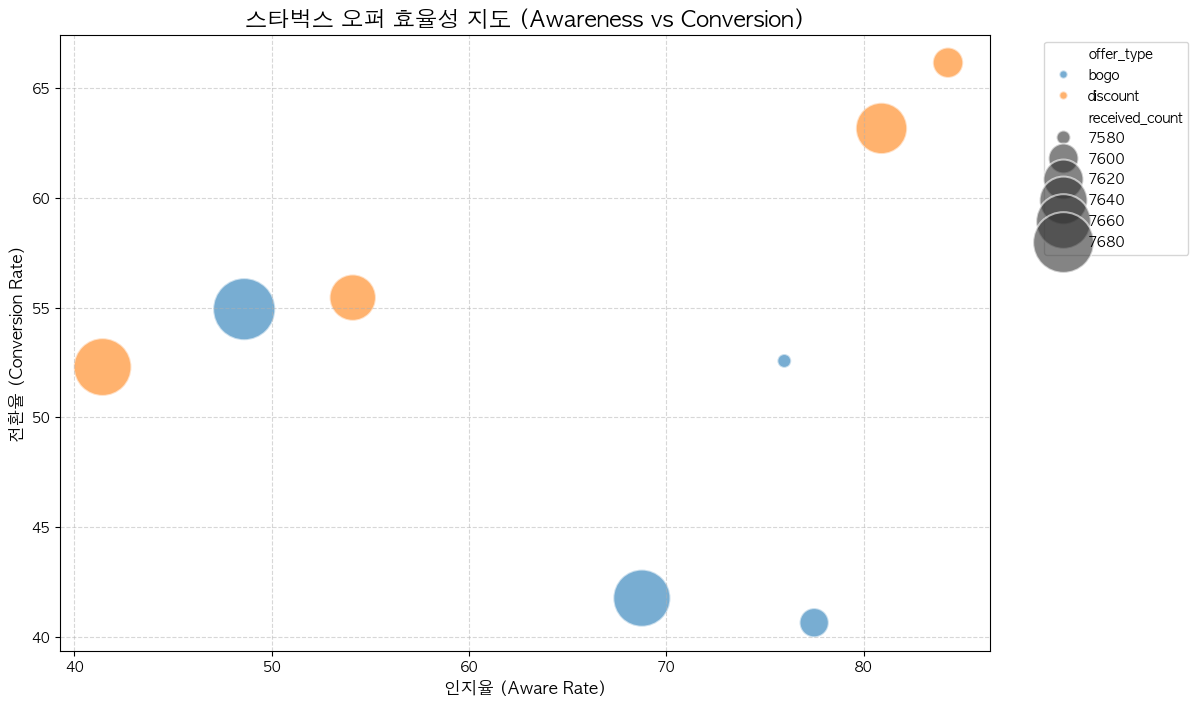

In [ ]:
plt.figure(figsize=(12, 8))
# x축: 인지율, y축: 전환율, 점의 크기: 발송 횟수, 색상: 오퍼 타입
sns.scatterplot(data=analysis_df.dropna(), x='aware_rate', y='conversion_rate', 
                size='received_count', hue='offer_type', sizes=(100, 2000), alpha=0.6)

plt.title('스타벅스 오퍼 효율성 지도 (Awareness vs Conversion)', fontsize=16)
plt.xlabel('인지율 (Aware Rate)', fontsize=12)
plt.ylabel('전환율 (Conversion Rate)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()